# Analyse linguistique : K-pop et Code-Switching (2000–2022)

Ce notebook répond à la question suivante :
> **La K-pop s'est-elle significativement anglicisée entre 2000 et 2022 ?**

# Introduction

## Contexte et motivations

Depuis les années 1990, la musique populaire coréenne, communément appelée K-pop,  s'est imposée comme l'un des phénomènes culturels les plus globalisés de ce siècle. Si ses origines sont ancrées dans une tradition musicale coréenne, la K-pop s'est très tôt distinguée par un trait linguistique singulier : le mélange délibéré du coréen et de l'anglais au sein d'une même chanson, parfois d'un même vers. Ce phénomène, désigné dans la littérature comme *code-switching* ou *code-mixing*, a été documenté dès le début des années 2000.

Lee (2004) est l'une des premières à analyser linguistiquement ce phénomène : elle identifie plusieurs niveaux d'insertion de l'anglais dans les paroles K-pop, allant des simples *fillers* vocaux (*oh*, *yeah*, *come on*) jusqu'à des phrases entières en anglais idiomatique, voire avec des traits propres à l'*African American Vernacular English* (AAVE). Pour Lee, ce mélange de codes n'est pas anodin : il constitue un espace d'affirmation identitaire pour la jeunesse coréenne, une façon de négocier entre valeurs locales et influences globales. Barnes-Sadler et al. (2025), dans une étude quantitative portant sur les albums charté en Corée entre 2000 et 2020, confirment que la proportion d'anglais dans les paroles K-pop a augmenté de façon mesurable sur cette période.

## Problématique et hypothèses

La présente étude s'inscrit dans ce corpus et propose d'en étendre la portée à travers un corpus original : les paroles référencées sur la plateforme **Genius** pour la période **2000 - 2022**. Ce corpus présente une particularité importante - il sur-représente les artistes disposant d'une audience anglophone internationale, ce qui en fait non pas un doublon des études sur les charts coréens, mais une **perspective complémentaire**, centrée sur la K-pop telle qu'elle est perçue et consommée à l'international.

Nous testons deux hypothèses :

**H1 : Hypothèse quantitative** : *Le ratio de tokens anglais dans les paroles K-pop du corpus Genius augmente significativement entre 2000 et 2022.*
Cette hypothèse est mesurée par deux métriques complémentaires : le ratio de tokens entièrement latins (`cs_ratio_tokens`) et le ratio de caractères latins (`cs_ratio_chars`). Si les deux convergent, les résultats sont robustes.

**H2 : Hypothèse qualitative** : *La richesse lexicale des tokens anglais augmente significativement sur la même période.*
Mesurée par le *Type-Token Ratio* anglais (`ttr_english`), cette hypothèse interroge la **nature** de l'anglais utilisé : s'agit-il de fillers répétitifs (*oh yeah yeah*) ou d'un vocabulaire anglais de plus en plus varié et structuré ?

## Données et méthode

Le corpus final comprend **30 462 chansons** issues de **728 artistes** identifiés comme K-pop sur la base d'un critère objectif (au moins 13 chansons détectées comme coréennes dans le dataset source). Toutes leurs chansons sont conservées, y compris celles entièrement en anglais, afin de capturer l'ensemble des pratiques de code-switching.

Les métriques sont calculées en une seule passe de tokenisation via spaCy, sur les paroles nettoyées (suppression des balises Genius). L'analyse temporelle repose sur trois outils statistiques :
- **Corrélation de Spearman** : mesure de la tendance monotone année ↔ métrique, sans hypothèse de normalité
- **Régression linéaire globale** : quantification de la pente sur l'ensemble de la période
- **Régressions par sous-période** (2000 - 2012 / 2013- 2022) : test de la stabilité de la tendance

Le seuil de significativité retenu est **p < 0.05**.

## Imports

In [9]:
import re
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from tqdm import tqdm

## 1. Chargement du dataset

In [10]:
# Chargement du dataset nettoyé produit par le notebook de préparation
df = pd.read_csv("kpop_dataset_clean.csv")

print(f"Dataset chargé : {len(df):,} chansons · {df['artist'].nunique():,} artistes")
print(f"Fenêtre        : {int(df['year'].min())}–{int(df['year'].max())}")
df.head(3)

Dataset chargé : 30,462 chansons · 728 artistes
Fenêtre        : 2000–2022


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language,is_korean,has_lyrics,lyrics_clean
0,Eat You Up Remix,rap,BoA (),2011,589,"{""Flo Rida"",""BoA (보아)""}","Yeah\nOne time, it's your boy, DJ Montay, righ...",11023,en,en,en,False,True,"Yeah\nOne time, it's your boy, DJ Montay, righ..."
1,Final Fantasy,rap,Tiger JK (JK),2011,544,"{""Roscoe Umali"",""Tiger JK (타이거JK)""}",So we representin' it\nCharter legend shit\nYo...,18258,en,en,en,False,True,So we representin' it\nCharter legend shit\nYo...
2,Umalis Bar,rap,Tiger JK (JK),2000,437,"{""Roscoe Umali"",""Tiger JK (타이거JK)""}","""I'm perfected\nMy drunken style like Sam Seed...",18262,en,en,en,False,True,"""I'm perfected\nMy drunken style like Sam Seed..."


## 2. Calcul des ratios

On calcule en **une seule passe de tokenisation** les trois métriques :

| Métrique | Formule | Ce qu'elle mesure |
|---|---|---|
| `cs_ratio_tokens` | tokens latins / tokens totaux | proportion de *mots* anglais |
| `cs_ratio_chars` | caractères latins / caractères totaux | proportion de *surface textuelle* anglaise |
| `ttr_english` | types anglais uniques / tokens anglais totaux | *richesse* du vocabulaire anglais |

In [11]:
# On charge un modèle spaCy vide (on n'a besoin que du tokeniseur)
nlp = spacy.blank("en")
nlp.max_length = 2_000_000

# On utilise regex : un token est « anglais » s'il est entièrement composé de lettres latines
LATIN_RE = re.compile(r'^[a-zA-Z]+$')

def compute_metrics(text: str) -> dict:
    """
    Calcule les trois métriques linguistiques pour une chanson.

    Retourne un dictionnaire avec :
      cs_ratio_tokens : mots latins / mots totaux
      cs_ratio_chars  : chars latins / chars totaux (hors espaces)
      ttr_english     : types anglais uniques / tokens anglais totaux
    """
    text = str(text)
    doc  = nlp(text)

    # Tous les tokens (sans ponctuation ni espaces)
    tokens = [t.text for t in doc if not t.is_space and not t.is_punct]

    # --- cs_ratio_tokens ---
    n_total        = len(tokens)
    latin_tokens   = [t for t in tokens if LATIN_RE.match(t)]   # mots entièrement latins
    n_latin        = len(latin_tokens)
    cs_tokens      = n_latin / n_total if n_total > 0 else 0.0

    # --- cs_ratio_chars ---
    n_chars_latin  = len(re.findall(r'[a-zA-Z]', text))
    n_chars_total  = len(re.sub(r'\s', '', text))                # tous les chars hors espaces
    cs_chars       = n_chars_latin / n_chars_total if n_chars_total > 0 else 0.0
    

    # --- ttr_english ---
    # On réutilise latin_tokens déjà extrait ci-dessus — pas de double tokenisation
    # On met en minuscule pour que 'Yeah' et 'yeah' comptent comme le même type
    n_types        = len(set(t.lower() for t in latin_tokens))
    ttr_english    = n_types / n_latin if n_latin > 0 else 0.0

    return {
        "cs_ratio_tokens" : cs_tokens,
        "cs_ratio_chars"  : cs_chars,
        "ttr_english"     : ttr_english,
    }


# Traitement par batches pour ne pas surcharger la mémoire
BATCH_SIZE = 1000
results = []

for i in tqdm(range(0, len(df), BATCH_SIZE), desc="Calcul métriques"):
    batch = df["lyrics_clean"].iloc[i : i + BATCH_SIZE]
    for text in batch:
        results.append(compute_metrics(text))

# Ajout des colonnes au dataframe
df_metrics = pd.DataFrame(results)
df = pd.concat([df, df_metrics], axis=1)

print(f"cs_ratio_tokens — moyen : {df['cs_ratio_tokens'].mean():.3f}  médian : {df['cs_ratio_tokens'].median():.3f}")
print(f"cs_ratio_chars  — moyen : {df['cs_ratio_chars'].mean():.3f}  médian : {df['cs_ratio_chars'].median():.3f}")
print(f"ttr_english     — moyen : {df['ttr_english'].mean():.3f}  médian : {df['ttr_english'].median():.3f}")

Calcul métriques: 100%|██████████| 31/31 [01:18<00:00,  2.55s/it]


cs_ratio_tokens — moyen : 0.355  médian : 0.312
cs_ratio_chars  — moyen : 0.411  médian : 0.402
ttr_english     — moyen : 0.347  médian : 0.322


## 3. Analyses temporelles

### Méthode statistique commune

Pour chacune des trois métriques, j'utilise le même protocole :

1. **Moyenne par année** : agrégation des valeurs par année pour obtenir une série temporelle.
2. **Régression linéaire globale** (scipy `linregress`) : mesure la tendance sur toute la période.
3. **Corrélation de Spearman** (scipy `spearmanr`) : mesure la corrélation monotone année ↔ métrique,  
   sans supposer une relation linéaire ni une distribution normale — plus robuste pour des données de corpus.
4. **Analyse par sous-période** 
   On teste chaque phase séparément pour quantifier ce changement de rythme.

**Seuil de significativité** : p < 0.05 pour tous les tests.

In [20]:
# Je définis une fonction unique pour éviter de dupliquer le même code trois fois (une fois par métrique).
# Elle produit : visualisation, régression globale, Spearman et phases.

def analyse_temporelle(serie: pd.Series, label: str, couleur: str,
                        phase1_fin: int = 2012) -> None:
        
    """
    Analyse complète d'une métrique temporelle.

    Paramètres :
        serie      : pd.Series indexée par année (valeurs moyennes)
        label      : nom de la métrique (pour les titres et légendes)
        couleur    : couleur principale du graphique
        phase1_fin : dernière année de la phase 1 (défaut : 2012)
    """
    
    years  = serie.index.astype(int)
    values = serie.values


    # --- Régression linéaire globale ---
    
    slope, intercept, r, p_lin, _ = stats.linregress(years, values)
    trend = slope * years + intercept


    # --- Test de Spearman ---
    
    rho, p_sp = stats.spearmanr(years, values)


    # --- Régressions par phase ---
    
    phase1 = serie.loc[:phase1_fin]
    phase2 = serie.loc[phase1_fin + 1:]
    s1, i1, r1, p1, _ = stats.linregress(phase1.index, phase1.values)
    s2, i2, r2, p2, _ = stats.linregress(phase2.index, phase2.values)


    # --- Visualisation ---
    
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(years, values, color=couleur, marker='o', linewidth=2.5,
            label=f"{label} (moyenne annuelle)", zorder=3)


    # Tendance globale
    ax.plot(years, trend, color='gray', linestyle='--', linewidth=1.5,
            label=f"Tendance globale (r={r:.2f}, p={p_lin:.3f})")


    # Tendances par phase
    ax.plot(phase1.index, s1 * phase1.index + i1,
            color='coral', linestyle='--', linewidth=2,
            label=f"Phase 1 : 2000–{phase1_fin} (R²={r1**2:.2f}, p={p1:.3f})")
    ax.plot(phase2.index, s2 * phase2.index + i2,
            color='green', linestyle='--', linewidth=2,
            label=f"Phase 2 : {phase1_fin+1}–2022 (R²={r2**2:.2f}, p={p2:.3f})")


    # Zones colorées pour les deux phases
    ax.axvspan(years.min(), phase1_fin,      alpha=0.06, color='coral')
    ax.axvspan(phase1_fin,  years.max() + 1, alpha=0.06, color='green')

    ax.set_title(f"Évolution de {label} dans les paroles K-pop (2000-2022)", fontsize=13)
    ax.set_xlabel("Année")
    ax.set_ylabel(label)
    ax.set_xticks(years)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.3f}"))
    plt.tight_layout()
    plt.show()

    # --- Résultats statistiques ---
    print(f"{'='*55}")
    print(f"RÉSULTATS — {label}")
    print(f"{'='*55}")
    print(f"Spearman  : ρ = {rho:.4f}  |  p = {p_sp:.4f}  " + ("<---- SIGNIFICATIF" if p_sp < 0.05 else "<---- non significatif"))
    print(f"Régression globale : pente = {slope:.5f}  |  R² = {r**2:.4f}  |  p = {p_lin:.4f}")
    print(f"Phase 1 (2000–{phase1_fin}) : pente = {s1:.5f}  |  R² = {r1**2:.4f}  |  p = {p1:.4f}")
    print(f"Phase 2 ({phase1_fin+1}–2022) : pente = {s2:.5f}  |  R² = {r2**2:.4f}  |  p = {p2:.4f}")
    print()

### 3.1 Proportion de mots anglais 

**Pourquoi cette mesure ?**  
C'est la mesure centrale de H1, directement comparable à Barnes-Sadler et al. (2025) qui utilisent également un ratio de tokens.  
Un token est considéré « anglais » s'il est entièrement composé de lettres latines (a–z, A–Z).  
Cette définition est conservative : un mot hybride coréen/latin n'est pas compté comme anglais.

**Limite :** un mot court répété 20 fois (*yeah yeah yeah*) pèse autant qu'un mot long utilisé une seule fois.

CS_ratio tokens par année :
year
2000    0.2716
2001    0.3045
2002    0.3090
2003    0.3226
2004    0.2199
2005    0.2587
2006    0.2536
2007    0.2434
2008    0.3061
2009    0.3558
2010    0.3966
2011    0.4160
2012    0.4189
2013    0.3716
2014    0.3365
2015    0.3971
2016    0.3559
2017    0.4059
2018    0.3756
2019    0.3287
2020    0.3288
2021    0.3327
2022    0.3726



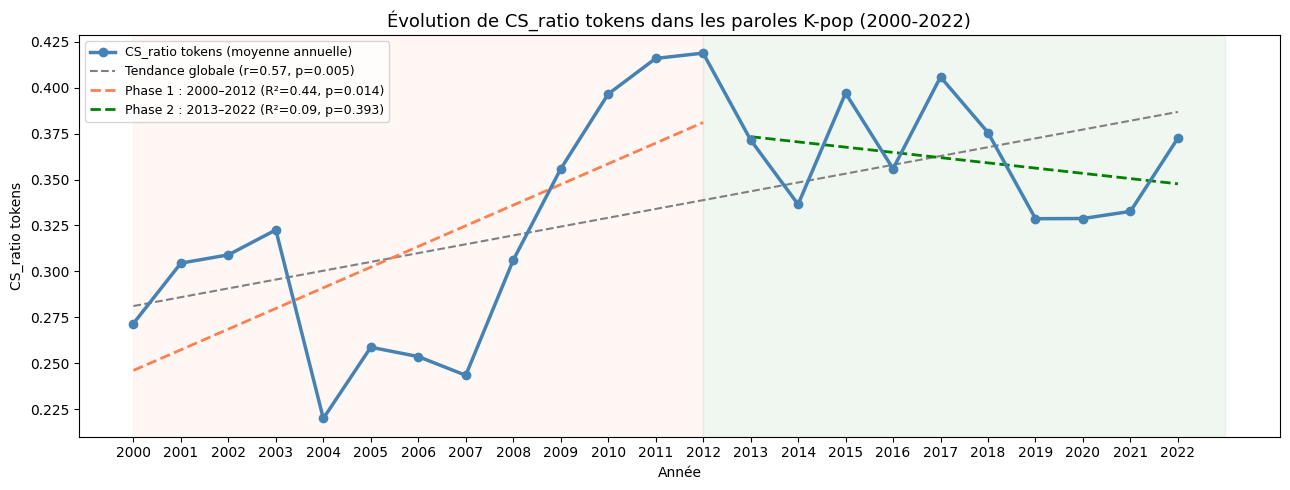

RÉSULTATS — CS_ratio tokens
Spearman  : ρ = 0.5988  |  p = 0.0025  <---- SIGNIFICATIF
Régression globale : pente = 0.00481  |  R² = 0.3234  |  p = 0.0046
Phase 1 (2000–2012) : pente = 0.01125  |  R² = 0.4385  |  p = 0.0137
Phase 2 (2013–2022) : pente = -0.00285  |  R² = 0.0923  |  p = 0.3935



In [21]:
# Moyenne du cs_ratio_tokens par année
cs_tokens_by_year = df.groupby("year")["cs_ratio_tokens"].mean().round(4)

print("CS_ratio tokens par année :")
print(cs_tokens_by_year.to_string())
print()

analyse_temporelle(cs_tokens_by_year,
                   label="CS_ratio tokens",
                   couleur="steelblue")

### 3.2 Proportion de caractères latins 

**Pourquoi cette mesure en complément ?**  
Le ratio de tokens traite chaque mot de façon égale, qu'il fasse 2 ou 10 lettres.  
Le ratio de *caractères* donne plus de poids aux mots longs, et capte mieux la « surface textuelle » occupée par l'anglais.  
Si les deux mesures convergent, les résultats de H1 sont robustes.  
Si elles divergent, cela signalerait que l'anglais se manifeste surtout sous forme de mots courts (fillers).

CS_ratio chars par année :
year
2000    0.3008
2001    0.3305
2002    0.3343
2003    0.3427
2004    0.2580
2005    0.2976
2006    0.2880
2007    0.2934
2008    0.3589
2009    0.4082
2010    0.4448
2011    0.4684
2012    0.4586
2013    0.4200
2014    0.3878
2015    0.4565
2016    0.4147
2017    0.4824
2018    0.4406
2019    0.3818
2020    0.3870
2021    0.3846
2022    0.4205



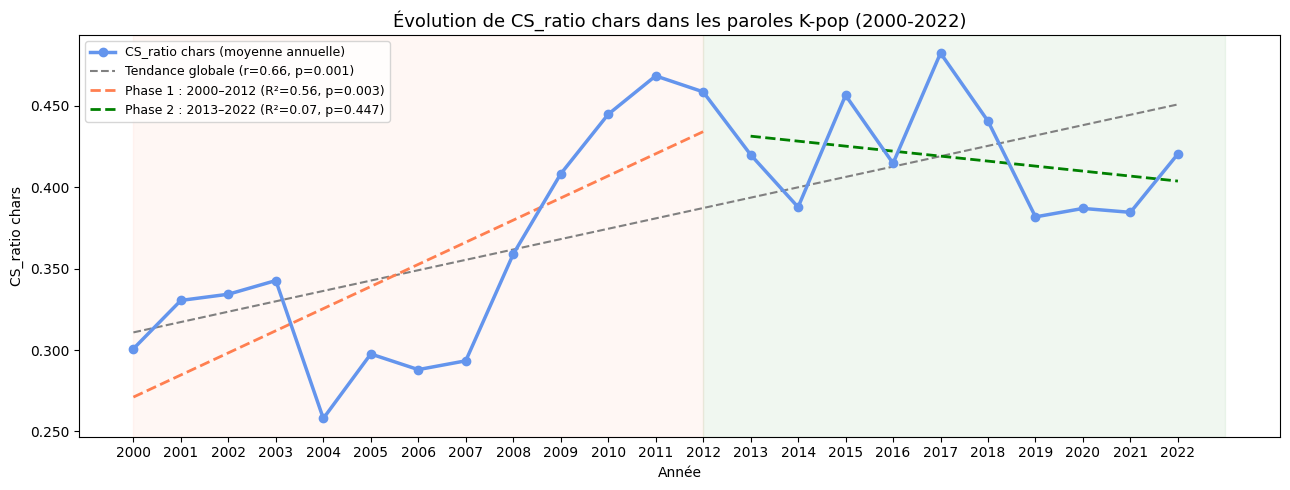

RÉSULTATS — CS_ratio chars
Spearman  : ρ = 0.6196  |  p = 0.0016  <---- SIGNIFICATIF
Régression globale : pente = 0.00637  |  R² = 0.4369  |  p = 0.0006
Phase 1 (2000–2012) : pente = 0.01358  |  R² = 0.5642  |  p = 0.0031
Phase 2 (2013–2022) : pente = -0.00307  |  R² = 0.0742  |  p = 0.4466



In [22]:
# Moyenne du cs_ratio_chars par année
cs_chars_by_year = df.groupby("year")["cs_ratio_chars"].mean().round(4)

print("CS_ratio chars par année :")
print(cs_chars_by_year.to_string())
print()

analyse_temporelle(cs_chars_by_year,
                   label="CS_ratio chars",
                   couleur="cornflowerblue")

## 3.3 Richesse lexicale

**Pourquoi cette mesure ?**  
Les ratios H1 mesurent la *quantité* d'anglais, mais pas sa *qualité*.  
Lee (2004) montre que le code-switching en K-pop va des simples fillers (*oh*, *yeah*) jusqu'à des phrases idiomatiques complexes avec traits AAVE.  
Le **TTR** (*Type-Token Ratio*) capture cette dimension :

$$\text{TTR}_{\text{anglais}} = \frac{\text{mots anglais uniques (types)}}{\text{total tokens anglais}}$$

- **TTR bas** → anglais répétitif (*yeah yeah yeah baby baby*) → filler
- **TTR élevé** → chaque mot anglais est différent → vocabulaire riche et varié

Si le TTR augmente en même temps que H1, cela confirme une anglicisation à la fois quantitative et qualitative.  

**Limite :** le TTR est sensible à la longueur du texte — il tend à baisser naturellement quand les paroles sont longues.  
On le calcule chanson par chanson et on agrège par année, ce qui maintient une comparabilité relative,  
mais cette limite sera mentionnée en conclusion.

*(On exclut les chansons sans aucun token anglais, pour lesquelles le TTR serait 0 par construction et non par manque de richesse.)*

TTR anglais par année (chansons avec tokens anglais seulement) :
year
2000    0.4674
2001    0.4699
2002    0.4105
2003    0.4416
2004    0.5148
2005    0.4492
2006    0.5050
2007    0.4808
2008    0.4997
2009    0.4244
2010    0.3833
2011    0.4125
2012    0.3837
2013    0.4133
2014    0.4324
2015    0.4194
2016    0.3936
2017    0.4168
2018    0.3945
2019    0.3820
2020    0.3981
2021    0.3953
2022    0.3875



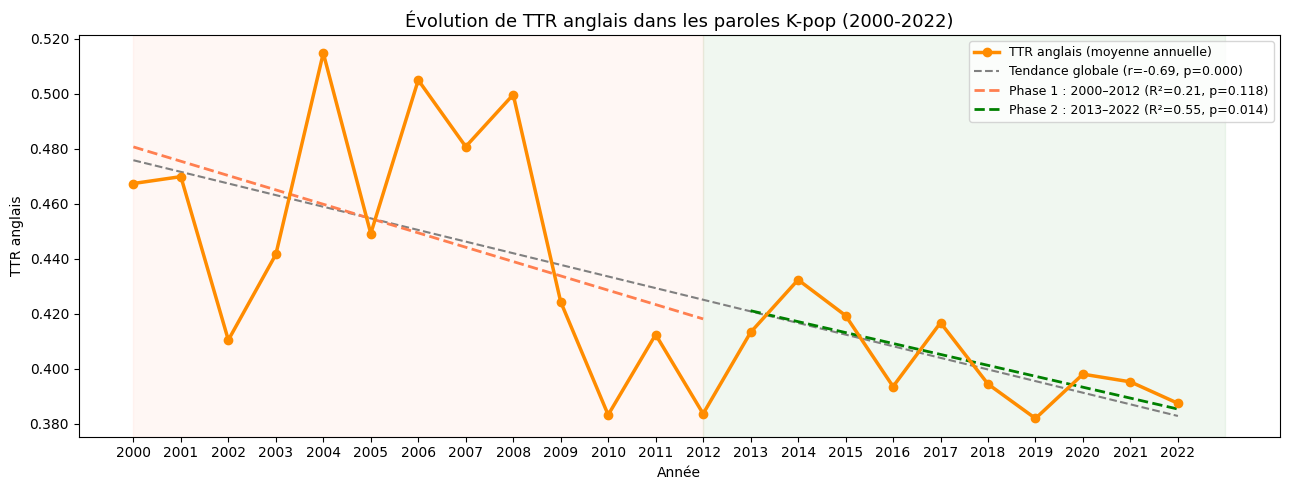

RÉSULTATS — TTR anglais
Spearman  : ρ = -0.6798  |  p = 0.0004  <---- SIGNIFICATIF
Régression globale : pente = -0.00423  |  R² = 0.4721  |  p = 0.0003
Phase 1 (2000–2012) : pente = -0.00521  |  R² = 0.2069  |  p = 0.1183
Phase 2 (2013–2022) : pente = -0.00397  |  R² = 0.5531  |  p = 0.0137



In [23]:
# On exclut les chansons sans tokens anglais (TTR = 0 par construction)
df_with_en = df[df["ttr_english"] > 0]

# Moyenne du TTR anglais par année
ttr_by_year = df_with_en.groupby("year")["ttr_english"].mean().round(4)

print("TTR anglais par année (chansons avec tokens anglais seulement) :")
print(ttr_by_year.to_string())
print()

analyse_temporelle(ttr_by_year,
                   label="TTR anglais",
                   couleur="darkorange")

# 6. Conclusion

## Synthèse des résultats

| Hypothèse | Métrique | ρ Spearman | p-value | Tendance globale | Interprétation |
|---|---|---|---|---|---|
| H1 | `cs_ratio_tokens` | +0.60 | 0.003 | +0.0048/an | Hausse significative |
| H1 (robustesse) | `cs_ratio_chars` | +0.62 | 0.002 | +0.0064/an | Convergente |
| H2 | `ttr_english` | −0.68 | 0.0004 | −0.0042/an | Baisse significative |

## H1 confirmée : une anglicisation quantitative significative

Les deux mesures de H1 convergent vers le même résultat : le ratio d'anglais dans les paroles K-pop a augmenté de façon statistiquement significative sur la période 2000–2022 (ρ = +0.60 pour les tokens, +0.62 pour les caractères ; p < 0.005 dans les deux cas). Ce résultat est cohérent avec ceux de Barnes-Sadler et al. (2025), qui observent la même tendance sur les albums charté en Corée entre 2000 et 2020.

L'analyse par sous-période révèle cependant une dynamique en deux temps :

- **Phase 1 (2000–2012) : croissance rapide.** La pente est forte et significative (pente ≈ +0.011/an pour les tokens, R² = 0.44, p = 0.014 ; pente ≈ +0.014/an pour les caractères, R² = 0.56, p = 0.003). Cette période correspond à l'émergence du Hallyu global : la K-pop cherche à s'exporter et l'anglais devient un vecteur stratégique d'accessibilité internationale, comme le notent Jin & Ryoo (2012).

- **Phase 2 (2013–2022) : stabilisation.** La tendance s'interrompt : la pente devient légèrement négative et non significative (p = 0.39 pour les tokens, p = 0.45 pour les caractères). Le ratio d'anglais oscille autour d'un plateau (~35–42 % pour les tokens). Cela suggère qu'une **norme de code-switching s'est établie** : les artistes maintiennent un niveau d'anglais élevé mais constant, signe d'une pratique devenue standard plutôt que croissante. Ce résultat prolonge l'observation de Lee (2004), qui décrit l'insertion d'anglais comme une pratique consciente et codifiée.

La convergence entre les deux mesures (tokens et caractères) renforce la robustesse de H1 : l'anglicisation n'est pas un artefact de mots courts répétés, elle occupe réellement une surface textuelle croissante dans les paroles.

## H2 infirmée dans sa formulation initiale : une richesse lexicale en baisse

Le résultat de H2 est à la fois surprenant et théoriquement éclairant. Contrairement à l'hypothèse d'une anglicisation qualitative croissante, le TTR anglais **diminue** significativement sur la période (ρ = −0.68, p = 0.0004 ; pente = −0.0042/an). Autrement dit, plus la K-pop utilise d'anglais en volume, moins ce vocabulaire anglais est varié.

L'analyse par sous-période précise cette tendance :
- **Phase 1 (2000–2012)** : la baisse est présente mais non significative (R² = 0.21, p = 0.118), avec une forte variance, le TTR est élevé mais instable, reflétant une hétérogénéité des pratiques d'anglicisation à cette époque.
- **Phase 2 (2013–2022)** : la baisse devient significative (R² = 0.55, p = 0.014), avec un TTR qui converge vers ~0.39–0.41. Cette stabilisation à un niveau bas indique une **homogénéisation du vocabulaire anglais** utilisé.

Ce résultat peut s'interpréter de deux façons complémentaires :

**1. L'effet mécanique du volume.** À mesure que le ratio d'anglais augmente, les paroles contiennent plus de tokens anglais totaux, ce qui fait mécaniquement baisser le TTR (plus un texte est long, plus les répétitions s'accumulent). Il est donc difficile d'affirmer que la richesse lexicale *réelle* diminue sans correction pour la longueur.

**2. La standardisation des *hooks* anglais.** La baisse du TTR est aussi cohérente avec l'observation de Lee (2004) sur les *fillers* : à mesure que l'anglais se banalise dans la K-pop, il se concentre sur un vocabulaire restreint et efficace à l'international (*baby*, *love*, *yeah*, *go*, *oh*). L'anglais devient moins un espace de créativité linguistique qu'un **code de signalement global**, utilisé pour renforcer l'accessibilité des chansons auprès d'audiences non-coréophones.

## Limites

**Biais du corpus Genius.** Les chansons référencées sur Genius sur-représentent les artistes disposant d'une communauté de fans anglophone active. Cela signifie que notre corpus est biaisé vers les artistes les plus internationaux, ce qui peut amplifier les tendances d'anglicisation par rapport aux charts coréens domestiques étudiés par Barnes-Sadler et al. (2025). Cette limite est aussi une contribution : notre étude mesure la K-pop *telle qu'elle est perçue à l'international*, une dimension complémentaire.

**Définition de l'anglais par l'alphabet.** On identifie les tokens anglais par leur composition en lettres latines. Or, certains mots coréens romanisés (*aegyo*, *daebak*, *noona*) seraient incorrectement comptés comme anglais. Cette limite est difficile à corriger sans modèle de détection de langue au niveau du token.

**TTR et longueur des textes.** Comme rappelé plus haut, le TTR décroît mécaniquement avec la longueur. Une analyse future pourrait recourir au **MTLD** (*Measure of Textual Lexical Diversity*), qui est invariant à la longueur du texte et permettrait de tester H2 de façon plus rigoureuse.

**Fenêtre 2000–2012 peu fournie.** Les années 2000 – 2008 contiennent peu de chansons (volumes faibles), ce qui rend les moyennes annuelles instables sur cette période et peut expliquer partiellement la forte variance observée en Phase 1.

## Perspectives

Ces résultats ouvrent plusieurs pistes de recherche : une analyse au niveau de l'artiste permettrait de tester H2 à une échelle individuelle (certains artistes maintiennent-ils un vocabulaire anglais plus riche ?). Une comparaison avec des corpus de J-pop ou de C-pop permettrait de contextualiser ces tendances dans un cadre pan-asiatique, dans la lignée des travaux de Lee (2004) sur la fonction identitaire de l'anglais dans les musiques populaires non-anglophones.